# Climate variations

![Westerhold et al, 2020](Climate.png "Westerhold et al, 202")

The Earth's climate varies with time on a range of time scales. Some of the most important ones are the so-called Milankovitch cycles that correspond to variations in the Earth's orbital characteristics. It is therefore convenient to investigate the effect of periodic (sinusoidal) climate variations at a range of periods, ranging from a few tens of kyrs to a few tens of Myrs, on the dynamic of mountain belts. To appreciate this, we will compute how periodic variations in precipitation rate affect both the height of a mountain belt and the sediment flux that it produces.

Note that to introduce variations in percipittion rate, we need to modify the drainage process to allow for non-uniform precipitation rate (in space and time)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from fastscape.models import basic_model
%load_ext xsimlab.ipython

In [2]:
from fastscape.processes import FlowAccumulator

model = basic_model.update_processes({'drainage': FlowAccumulator})

In [3]:
nx,ny = 401, 201
xl,yl = 100e3, 50e3
x,y = np.meshgrid(np.linspace(0,xl,nx), np.linspace(0,yl,ny))
tf = 10e6
tstep = xr.DataArray(np.linspace(0,tf,201), dims='tstep')
time = xr.DataArray(np.linspace(0,tf,201), dims='time')
period = 1e6
precip = 1 + 0.5*np.sin(tstep/period*2*np.pi)

In [4]:
# %create_setup model
import xsimlab as xs

ds_in = xs.create_setup(
    model=model,
    clocks={'tstep':tstep, 'time':time},
    master_clock='tstep',
    input_vars={
        'grid__shape': [ny,nx],
        'grid__length': [yl,xl],
        'boundary__status': ['looped','looped','fixed_value','fixed_value'],
        'uplift__rate': 1e-4,
        'init_topography__seed': None,
        'diffusion__diffusivity': 0.1,
        'drainage__runoff': precip,
        'spl__k_coef': 1e-5,
        'spl__area_exp': 0.45,
        'spl__slope_exp': 1,
    },
    output_vars={'topography__elevation':'time',
                 'drainage__flowacc':'time',
                 'erosion__rate':'time'}
)


In [5]:
with model, xs.monitoring.ProgressBar():
    ds_out = ds_in.xsimlab.run()

             0% | initialize 

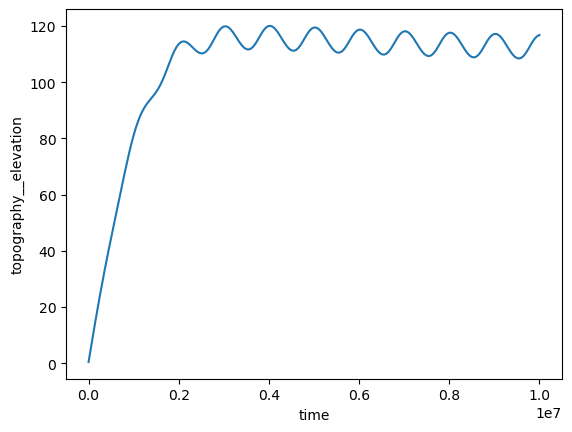

In [6]:
ds_out.topography__elevation.mean(('x','y')).plot();

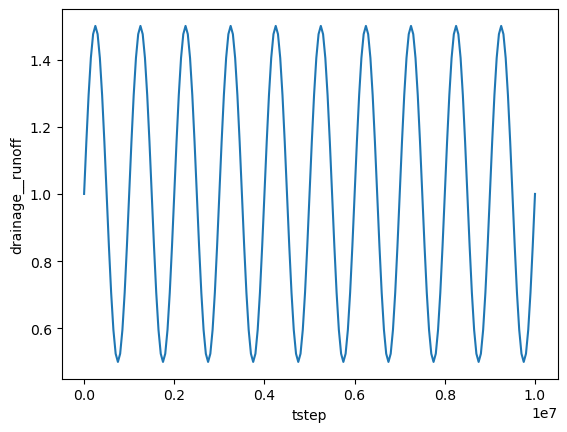

In [7]:
ds_out.drainage__runoff.plot()

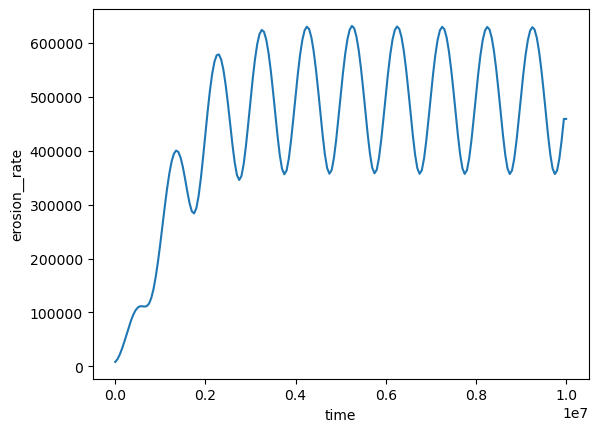

In [8]:
ds_out.erosion__rate.integrate(('x','y')).plot()

In [42]:
var_period = xr.DataArray([0.25e6,1e6,5e6], dims='period')

with model, xs.monitoring.ProgressBar():
    ds_out_var = (ds_in
              .xsimlab.update_vars(input_vars=({'drainage__runoff': 1 + 0.5*np.sin(tstep/var_period*2*np.pi)}))
              .xsimlab.run(batch_dim='period', check_dims='transpose')
              .assign_coords({'period':var_period}))

             0% | initialize 

             0% | initialize 

             0% | initialize 

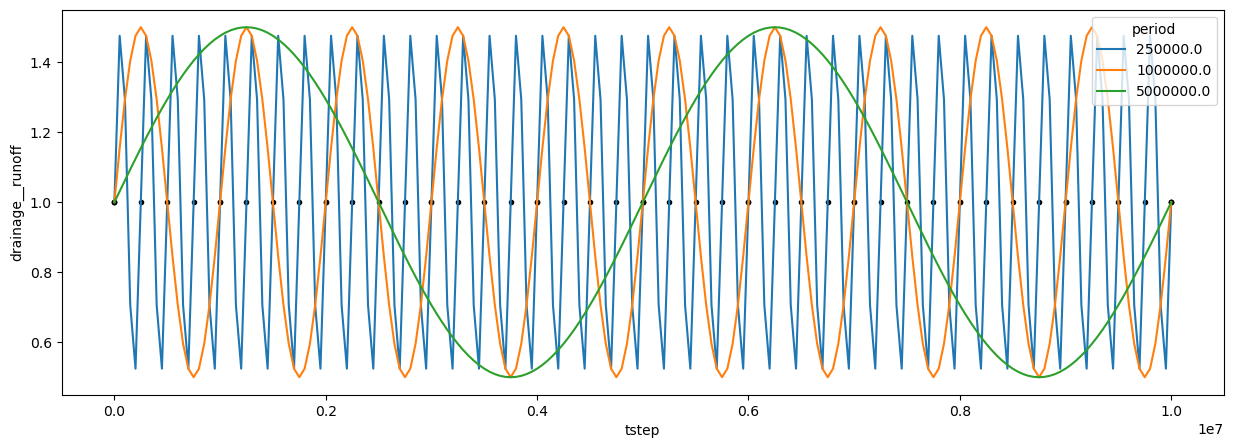

In [53]:
fig,ax = plt.subplots(figsize=(15,5))
ds_out_var.drainage__runoff.where(ds_out_var.tstep%ds_out_var.period==0).plot.line(ax=ax, x='tstep', marker='o', markersize=3, color='black')
ds_out_var.drainage__runoff.plot.line(ax=ax, x='tstep');

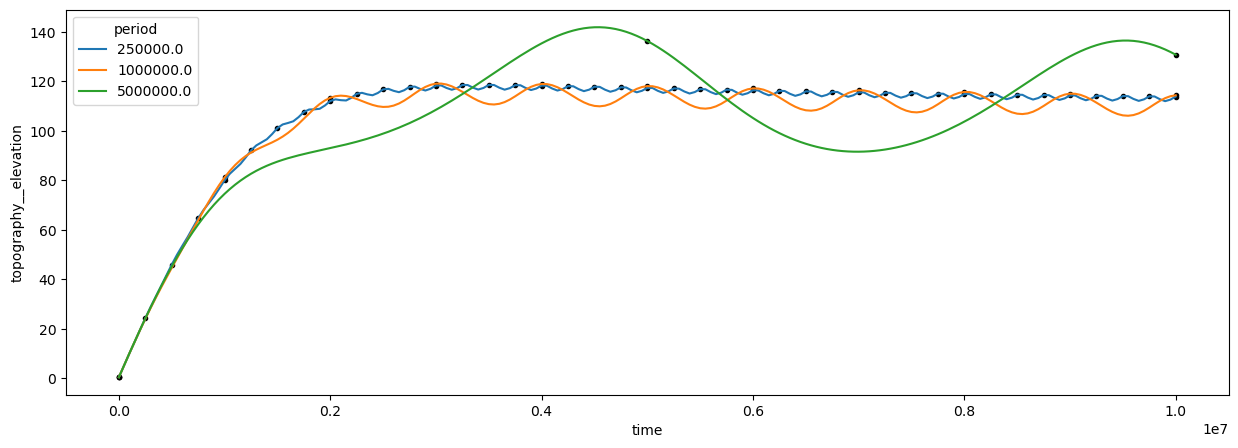

In [54]:
fig,ax = plt.subplots(figsize=(15,5))
ds_out_var.topography__elevation.mean(('x','y')).where(ds_out_var.time%ds_out_var.period==0).plot.line(ax=ax, x='time', marker='o', markersize=3, color='black')
ds_out_var.topography__elevation.mean(('x','y')).plot.line(ax=ax, x='time');


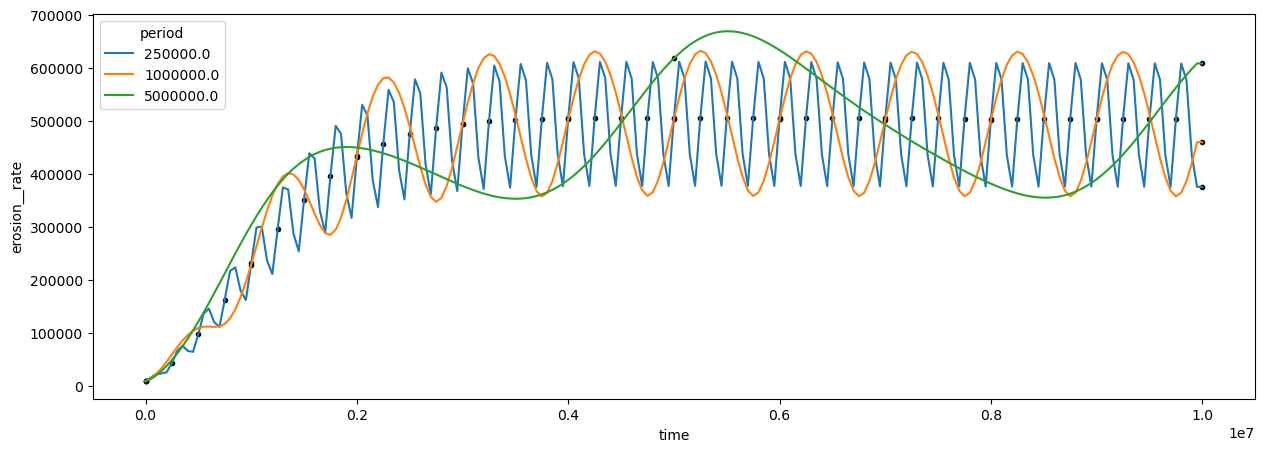

In [57]:
fig,ax = plt.subplots(figsize=(15,5))
ds_out_var.erosion__rate.integrate(('x','y')).where(ds_out_var.time%ds_out_var.period==0).plot.line(ax=ax, x='time', marker='o', markersize=3, color='black')
ds_out_var.erosion__rate.integrate(('x','y')).plot.line(ax=ax, x='time');